# [LAB-10] 6. [PBT] Apple Quality
# 1. 작업개요

## # 01. 준비작업
### 라이브러리 참조

In [1]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
from IPython.display import display, Markdown

from pandas import DataFrame

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: develop


### 2. 데이터 가져오기

In [2]:
origin = load_data("apple_quality")
origin

📚 이 데이터 세트는 다양한 과일 속성에 대한 정보를 담고 있어 과일의 특성을 파악하는 데 도움이 됩니다. 데이터 세트에는 과일 ID, 크기, 무게, 당도, 아삭함, 과즙량, 숙성도, 산도 및 품질과 같은 세부 정보가 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality)

field        description
-----------  ----------------------------------
A_id         각 과일에 대한 고유 식별자
Size         크기
Weight       무게
Sweetness    단맛 정도
Crunchiness  과일의 아삭한 식감을 나타내는 질감
Juiciness    과일의 과즙 함량 정도
Ripeness     과일이 익은 정도
Acidity      과일의 산도 수준
Quality      과일의 전반적인 품질



,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good
...,...,...,...,...,...,...,...,...,...
3995,3995,0.059,-1.067,-3.715,0.473,1.698,2.244,0.138,bad
3996,3996,-0.293,1.949,-0.204,-0.640,0.025,-1.088,1.854,good
3997,3997,-2.635,-2.138,-2.440,0.657,2.200,4.764,-1.335,bad
3998,3998,-4.008,-1.779,2.366,-0.200,2.161,0.214,-2.230,good


### 3. 컬럼 의미를 정리한 딕셔너리

In [3]:
column_means = {
    'A_id': '사과 식별자',
    'Size' : '크기',
    'Weight' : '무게',
    'Sweetness': '단맛 정도',
    'Crunchiness': '아삭한 식감',
    'Juiciness': '과즙 함량',
    'Ripeness': '익은 정도',
    'Acidity': '산도',
    'Quality': '품질(good / bad)',
}

### 연습문제 01
- 1. 데이터를 불러왔을 때, 원본 데이터의 관측치(행)은 몇개인가요? 4000행
- 2. 원본 데이터는 몇개의 컬럼으로 이루어져 있나요? 9개

## #02. 데이터 품질점검
### 1. 자료형 확인

In [4]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   str    
dtypes: float64(7), int64(1), str(1)
memory usage: 295.1 KB


### 2. 자료형 변환
- A_id는 행마다 값이 모두 다른 식별자이므로 분석 대상이 아니다. 여기서 제거한다.
    - 숫자로 저장되어 있어 그대로 두면 연속형 독립변수로 잘못 투입된다.
- 종속변수 Quality는 문자열이므로 명목형(category)으로 변환한다.

In [5]:
df0 = origin.drop(columns=['A_id'])
df1 = my_qtcheck.set_type(df0, as_category=['Quality'])

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Size         4000 non-null   float64 
 1   Weight       4000 non-null   float64 
 2   Sweetness    4000 non-null   float64 
 3   Crunchiness  4000 non-null   float64 
 4   Juiciness    4000 non-null   float64 
 5   Ripeness     4000 non-null   float64 
 6   Acidity      4000 non-null   float64 
 7   Quality      4000 non-null   category
dtypes: category(1), float64(7)
memory usage: 222.8 KB


### 3. 데이터 중복 점검

In [6]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


### 4. 결측치 점검

In [7]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
Size,0,0.000
Weight,0,0.000
Sweetness,0,0.000
Crunchiness,0,0.000
Juiciness,0,0.000
Ripeness,0,0.000
Acidity,0,0.000
Quality,0,0.000


### 5. 명목형 변수의 기술 통계량

In [8]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

컬럼 'Quality'의 value_counts():


,count
Quality,
bad,1996
good,2004


,Quality
count,4000
unique,2
top,good
freq,2004


### 6. 연속형 변수의 기술통계량

In [9]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc.T

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,-0.503,-0.990,-0.470,0.985,0.512,0.498,0.077
std,1.928,1.603,1.943,1.403,1.930,1.874,2.110
min,-7.152,-7.150,-6.894,-6.055,-5.962,-5.865,-7.011
25%,-1.817,-2.012,-1.738,0.063,-0.801,-0.772,-1.377
50%,-0.514,-0.985,-0.505,0.998,0.534,0.503,0.023
75%,0.806,0.031,0.802,1.894,1.836,1.766,1.510
max,6.406,5.791,6.375,7.620,7.364,7.238,7.405
rel_diff,-0.021,-0.005,-0.068,0.013,0.041,0.010,2.400
rdiff_flag,similar,similar,similar,similar,similar,similar,large_diff


## #03. 변수 유형 분류와 EDA 범위
### 1. 변수 유형 분류
- 선형회귀 때와 코드는 그대로이고, taget_is_continuous만 False로 바꾼다.

In [10]:
target ='Quality'   # 종속변수
taget_is_continuous = False  # 종속변수 연속형 여부 --> 로지스틱이므로 False
nominal_cols = my_qtcheck.get_categorical_column_names(df2)  # 명목형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)    # 연속형 변수

if taget_is_continuous:
    continuous_cols.remove(target)  # 연속형 변수 이름에서 종속변수 항목 제거
else:
    nominal_cols.remove(target)     # 명목형 변수 이름에서 종속변수 항목 제거

print('종속변수 :', target)
print('종속변수 유형 :' + ("연속형" if taget_is_continuous else "명목형"))
print('명목형   :', nominal_cols)
print('연속형   :', continuous_cols)

종속변수 : Quality
종속변수 유형 :명목형
명목형   : []
연속형   : ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']


### 2. 서열척도 적용(필요에 따라 수행)
- 명목형 범주에 순서가 있다면 순서를 지정한다(도메인 지식이 필요한 부분)
    - 이 데이터셋에는 서열척도 대상이 없다. 코드는 다른 데이터셋에 그대로 옮겨 쓸 수 있도록 남겨 둔다.

In [11]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# → 도메인 지식이 필요한 부분이다.
# → 서열척도 대상이 없는 데이터셋이라면 빈 딕셔너리로 둔다.
ordinal_map ={}

# 정의된 내용에 다라 순서를 재지정한다.
# → 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
df =df2.copy()

for col, order in ordinal_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 : {order}")
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

### 연습문제 02
- 3. 분석 대상이 아닌 컬럼을 제거하고 나면, 남은 데이터는 몇개의 컬럼이 되나요? 8개
- 4. 7가지 연속형 측정 항목 중 이상치가 가장 많이 섞여있는 항목은 무엇인가요? Weight
- 5. 반대로, 이상치가 가장 적게 섞여 있는 항목은 무엇인가요? Acidity

## #04. 단변량 분석
### 1. 명목형 종속변수에 대한 단변량 분석
- 선형회귀에서는 종속변수의 분포 모양(왜도, 이상치)을 봤지만, 로지스틱 회귀에서는 종속변수의 범주 비율(균형 여부)을 본다.

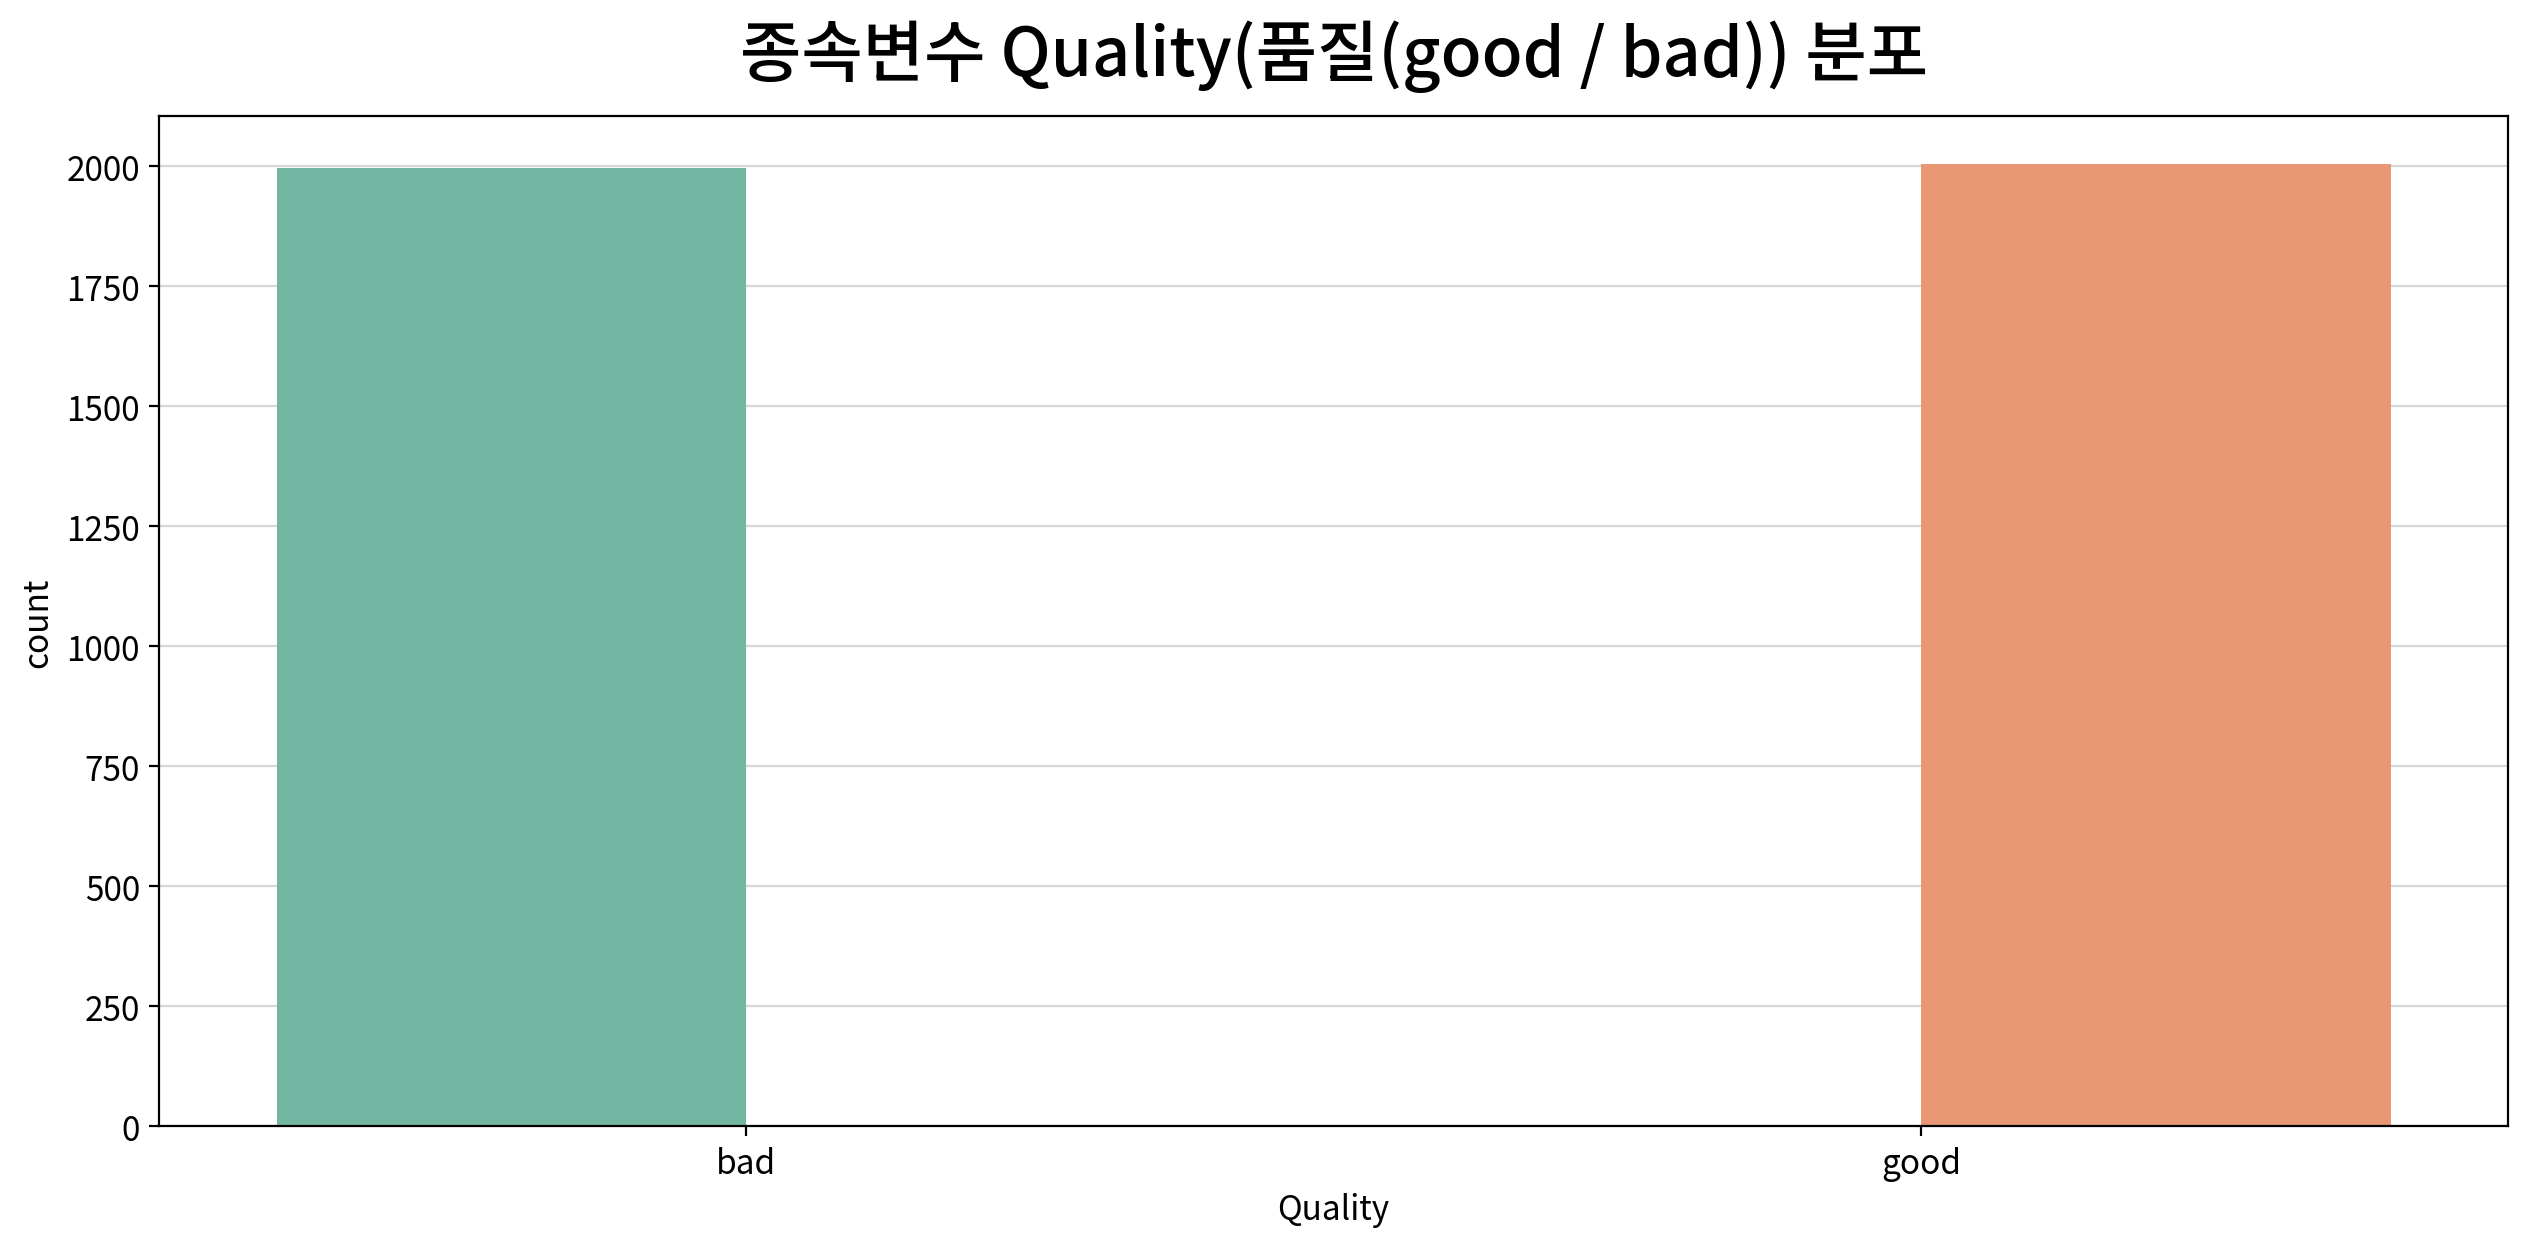

,count,unique,top,freq
Quality,4000,2,good,2004


,빈도,비율
Quality,,
good,2004,0.501
bad,1996,0.499


In [12]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette='Set2',
                  title=f'종속변수 {target}({column_means[target]}) 분포')

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq =df[target].value_counts().rename('빈도').to_frame()
# value_counts(nomalize=True)
# → 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
freq['비율'] = df[target].value_counts(normalize=True)
display(freq)

### 2. 연속형 독립변수에 대한 단변량 분석

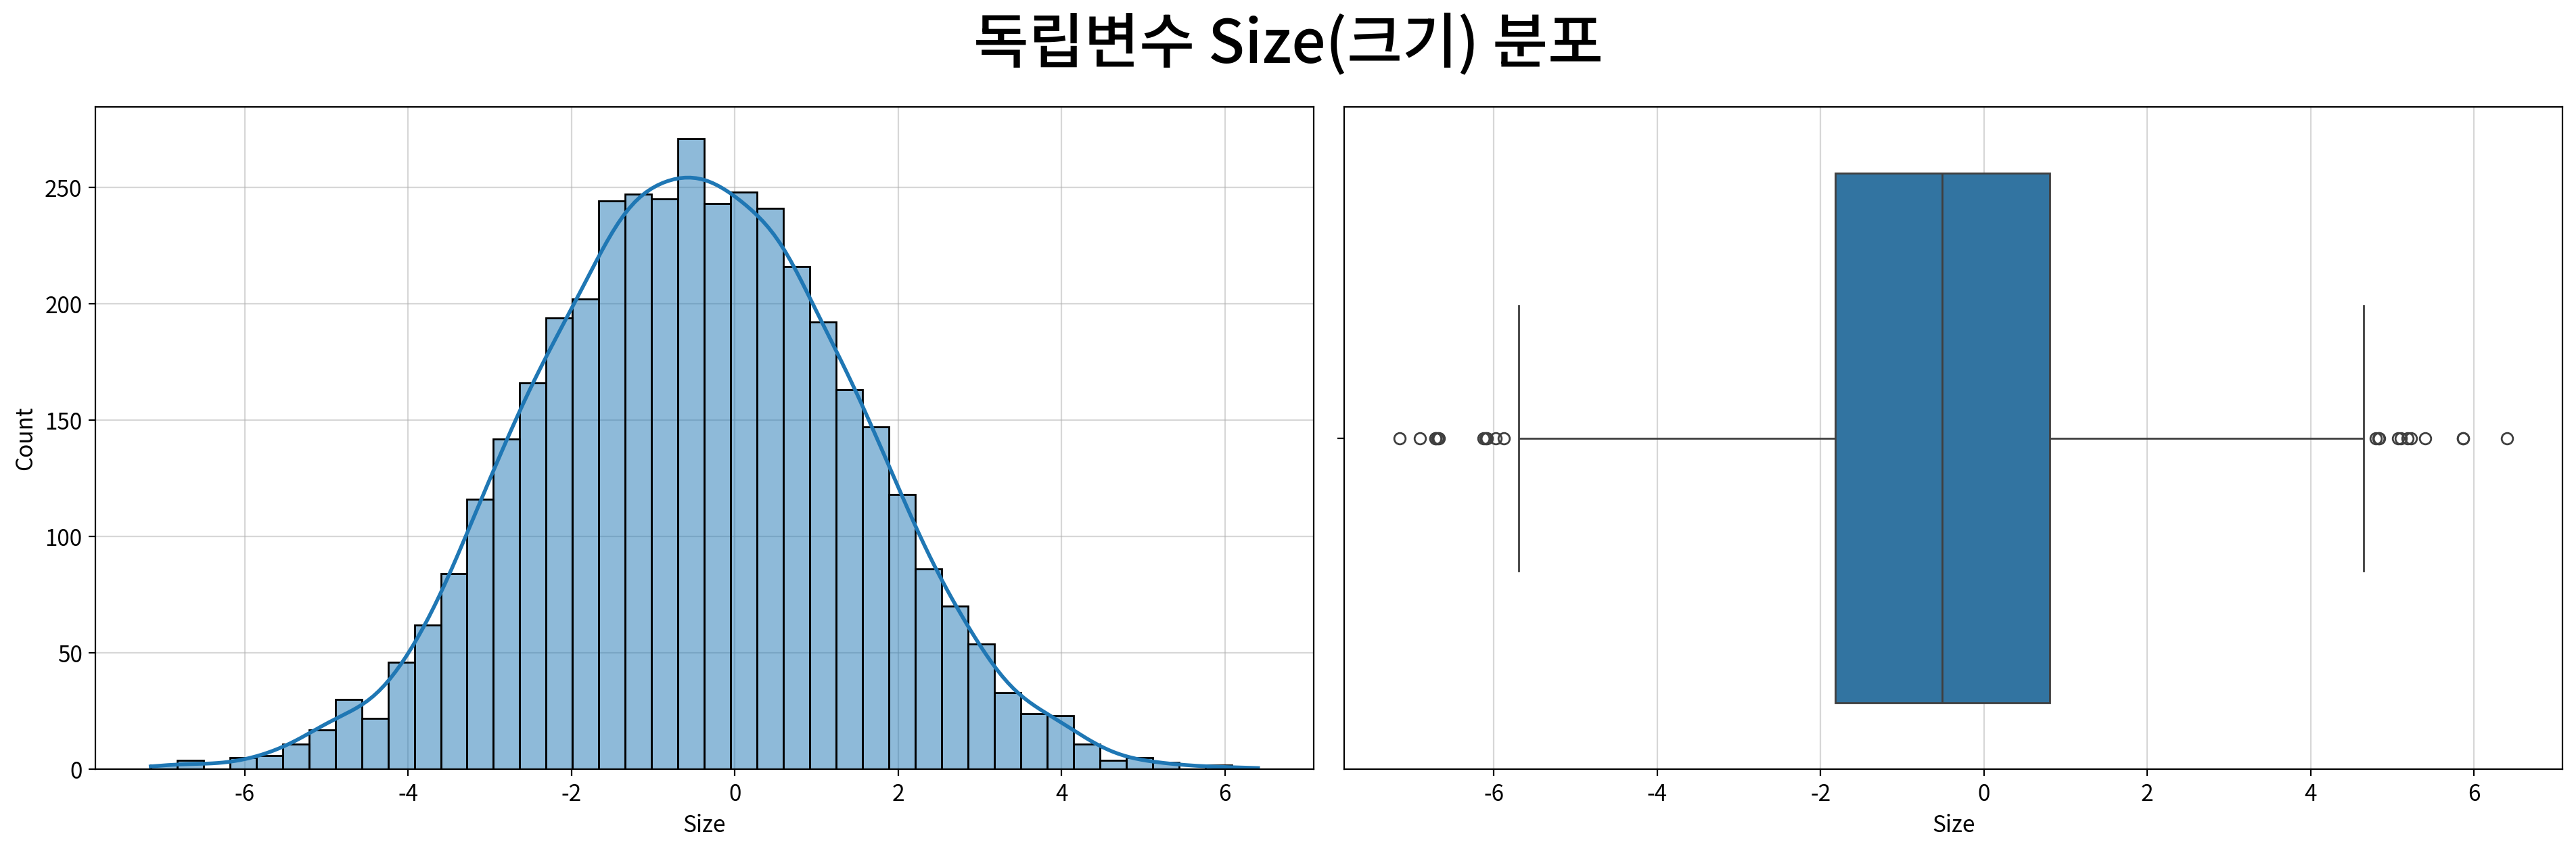

,Size
count,4000.000
mean,-0.503
std,1.928
min,-7.152
25%,-1.817
50%,-0.514
75%,0.806
max,6.406
rel_diff,-0.021
rdiff_flag,similar


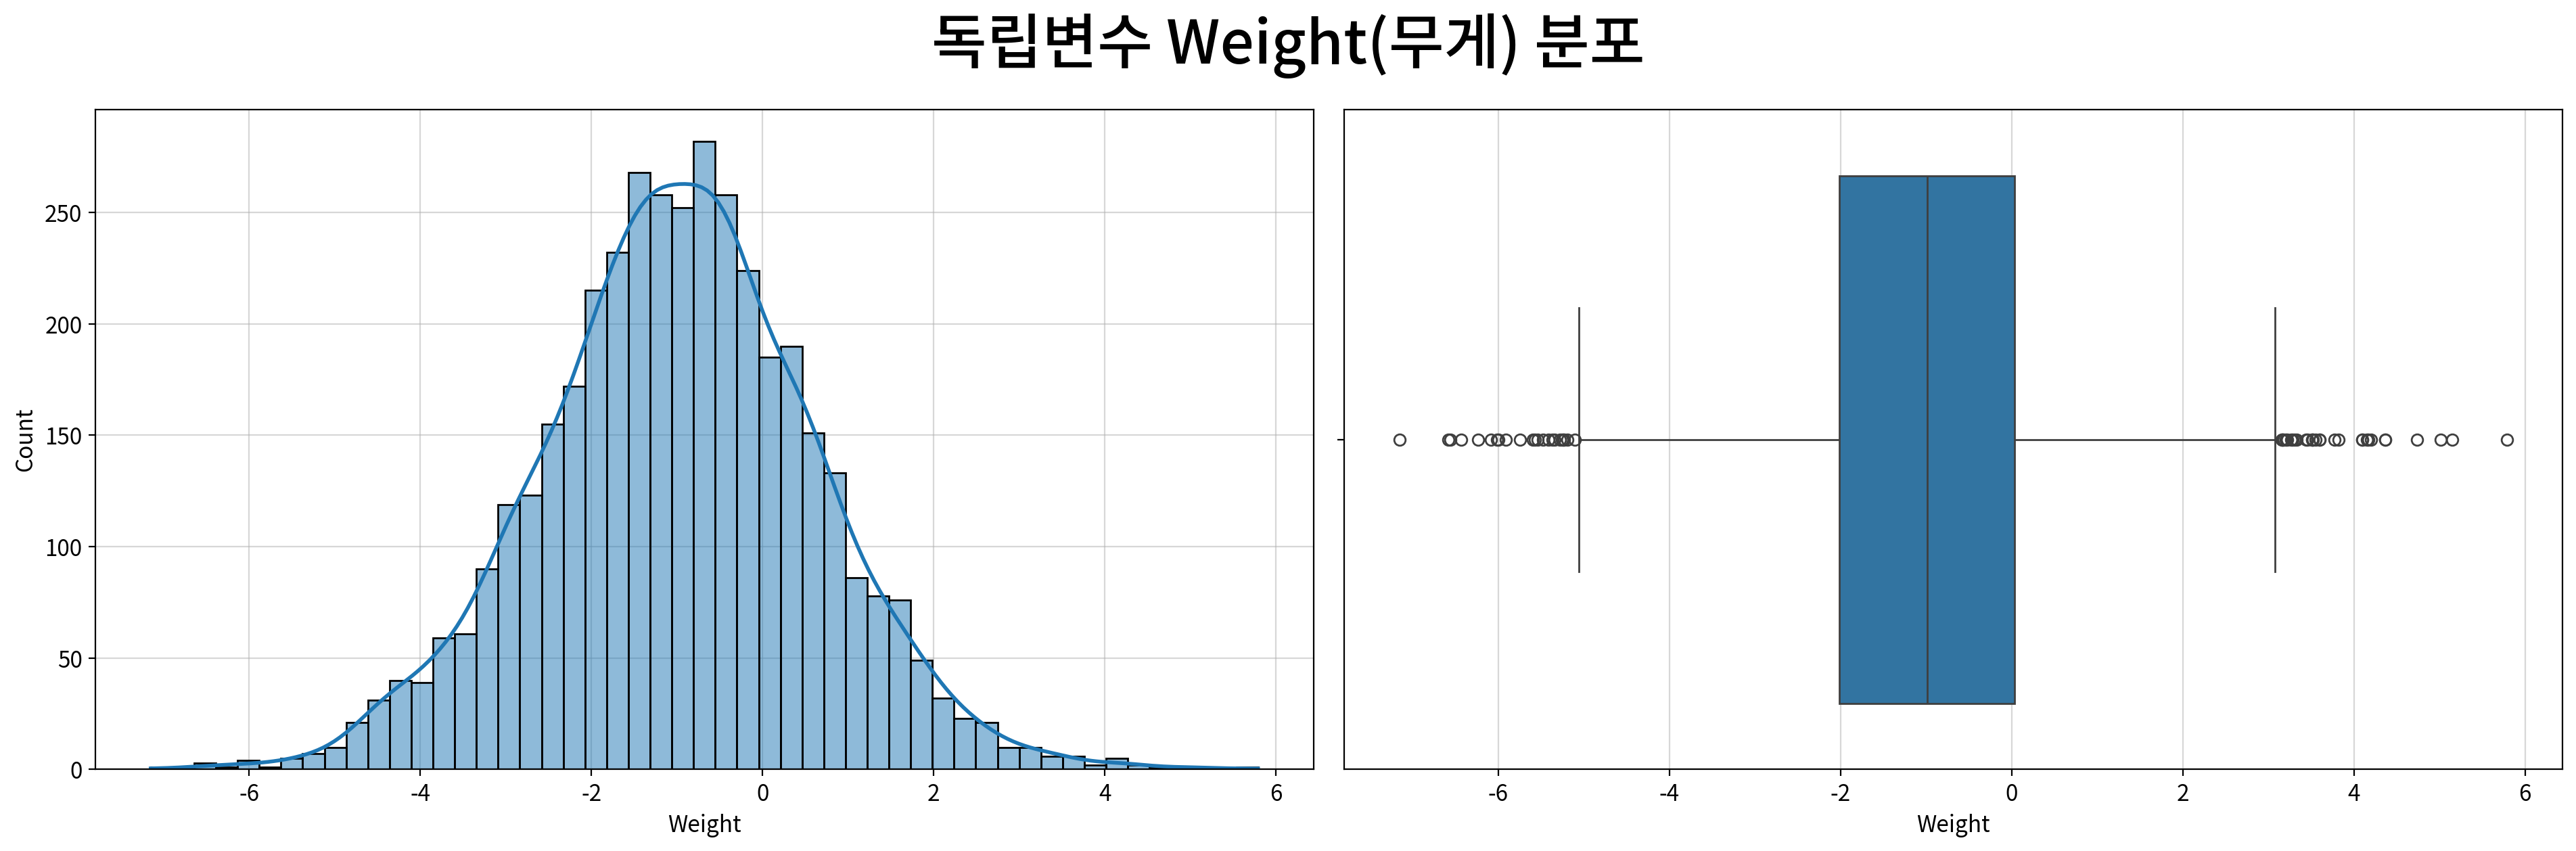

,Weight
count,4000.000
mean,-0.990
std,1.603
min,-7.150
25%,-2.012
50%,-0.985
75%,0.031
max,5.791
rel_diff,-0.005
rdiff_flag,similar


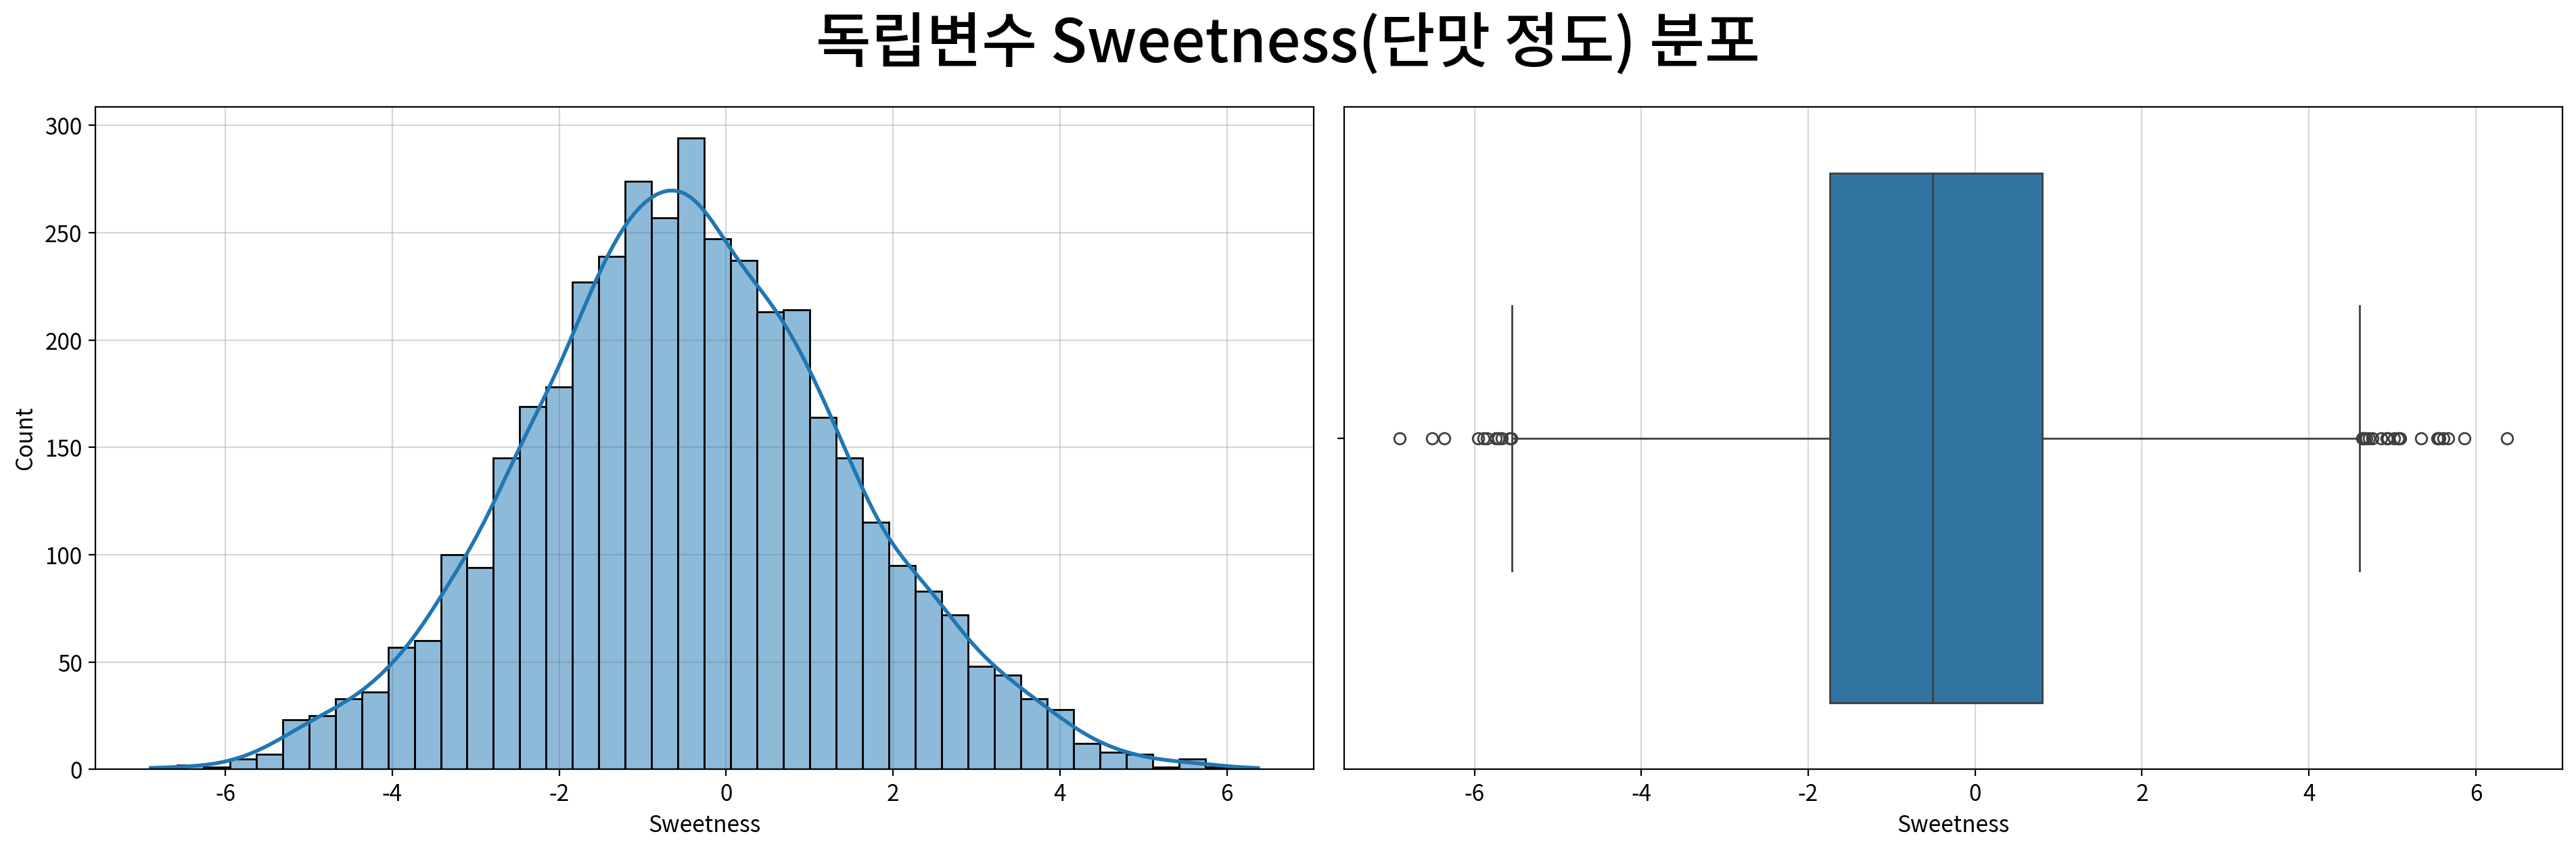

,Sweetness
count,4000.000
mean,-0.470
std,1.943
min,-6.894
25%,-1.738
50%,-0.505
75%,0.802
max,6.375
rel_diff,-0.068
rdiff_flag,similar


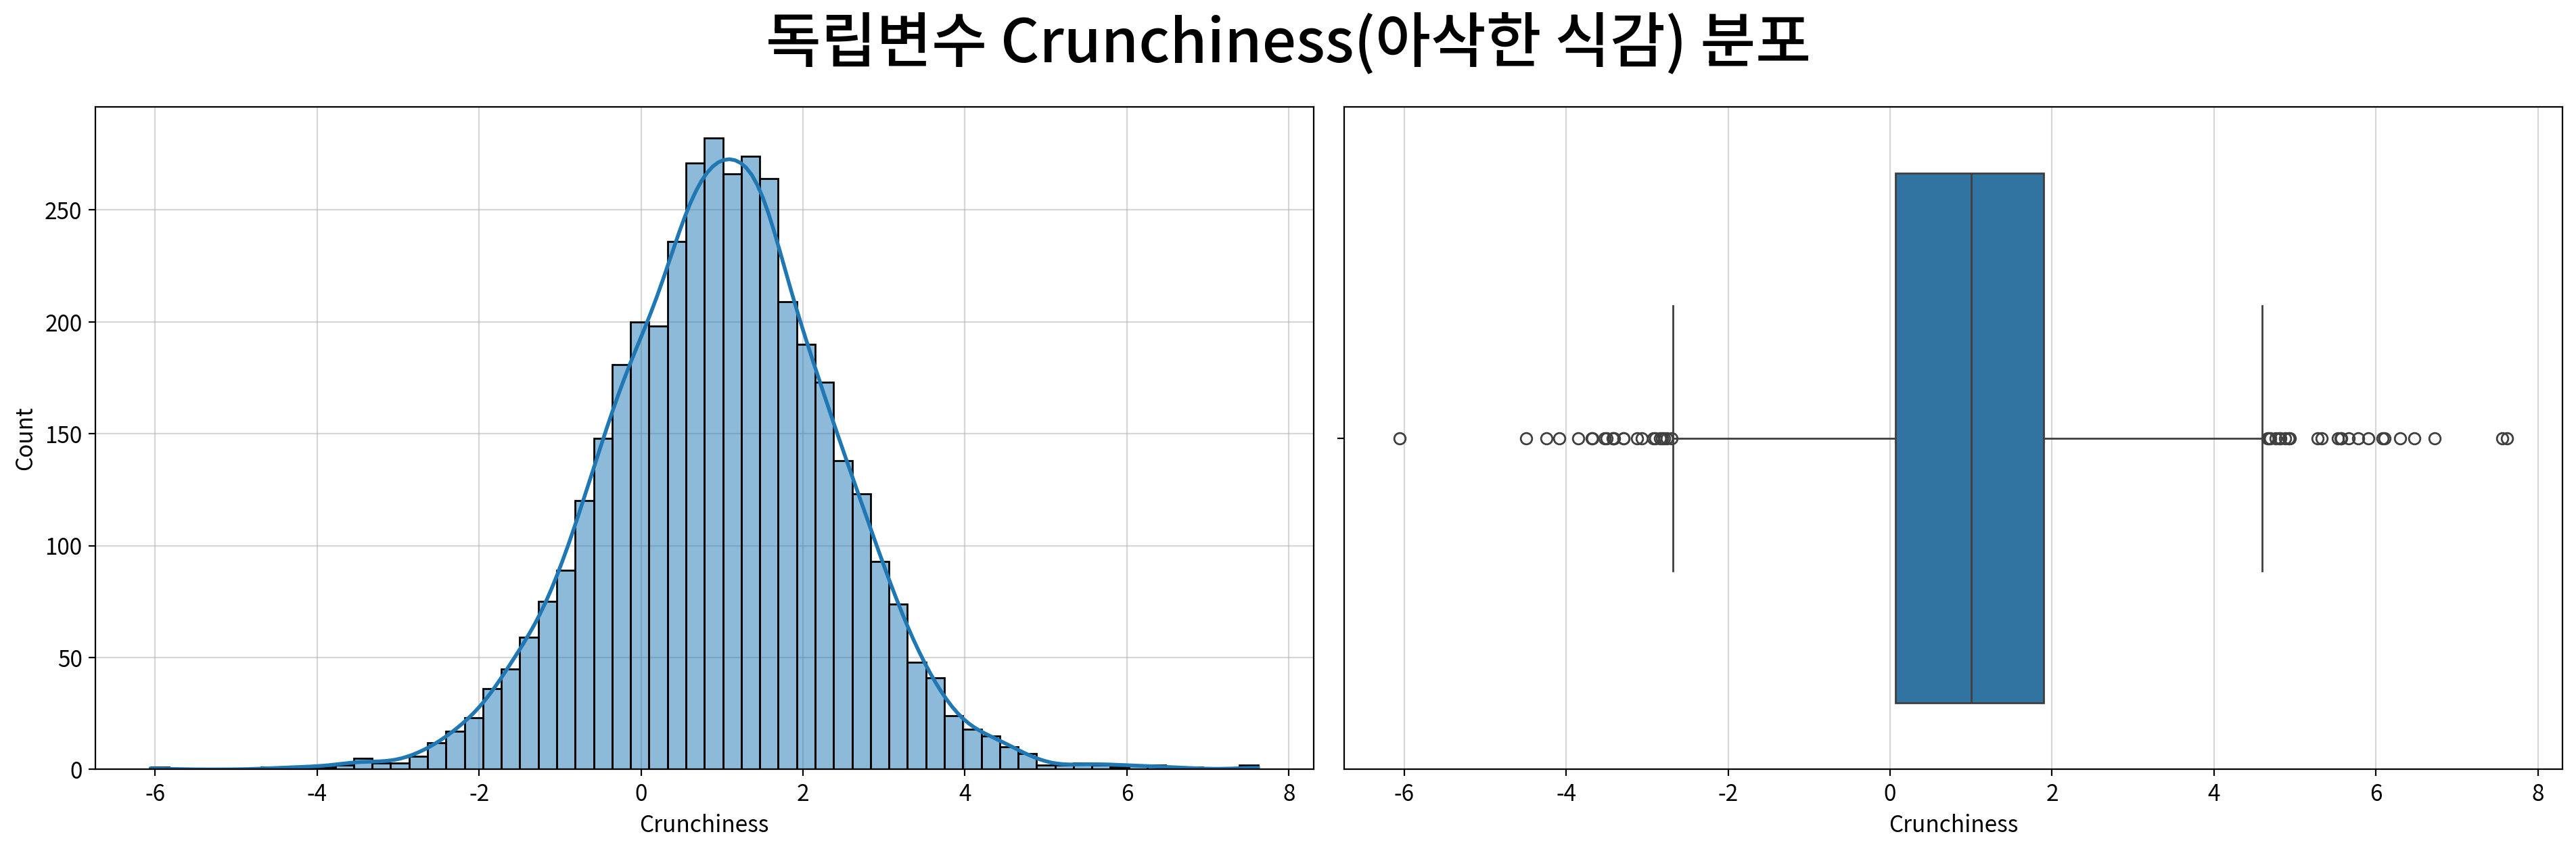

,Crunchiness
count,4000.000
mean,0.985
std,1.403
min,-6.055
25%,0.063
50%,0.998
75%,1.894
max,7.620
rel_diff,0.013
rdiff_flag,similar


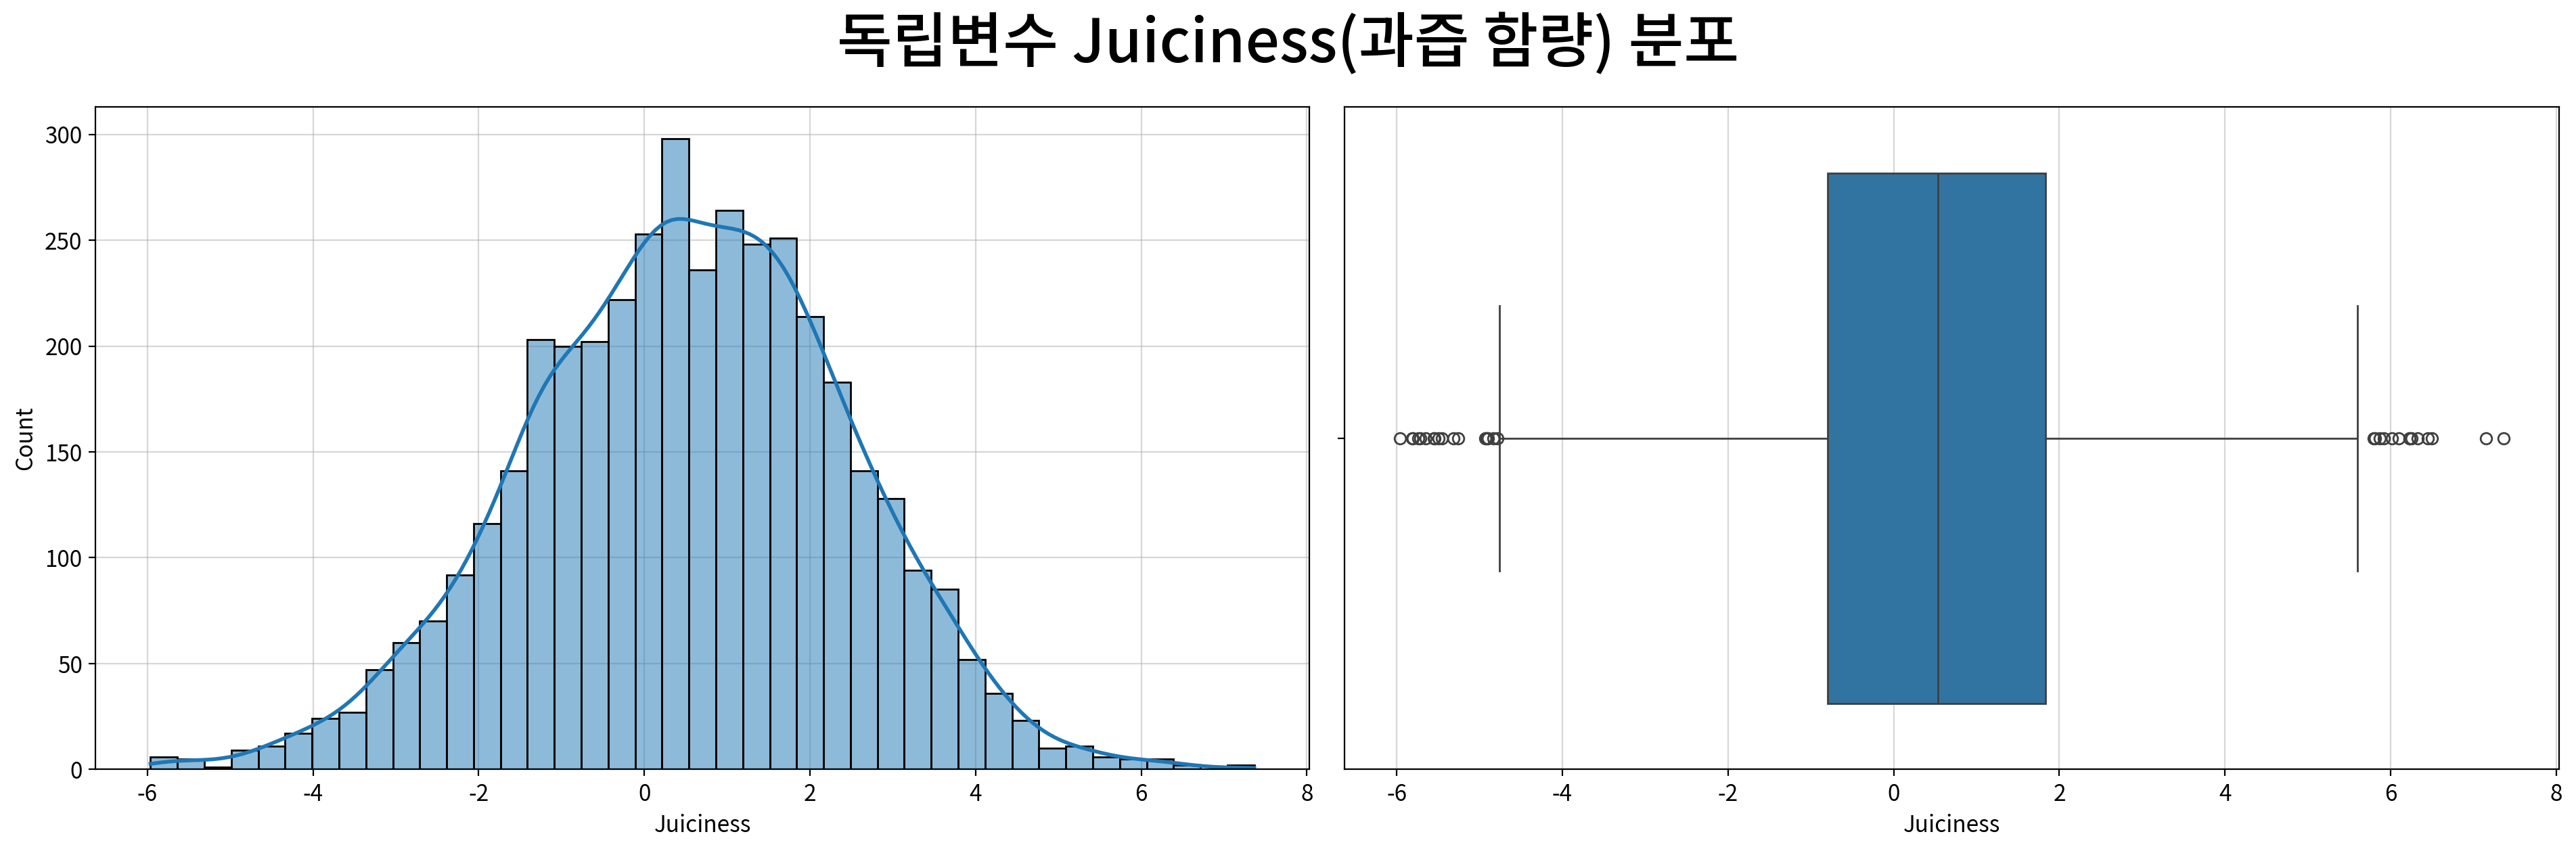

,Juiciness
count,4000.000
mean,0.512
std,1.930
min,-5.962
25%,-0.801
50%,0.534
75%,1.836
max,7.364
rel_diff,0.041
rdiff_flag,similar


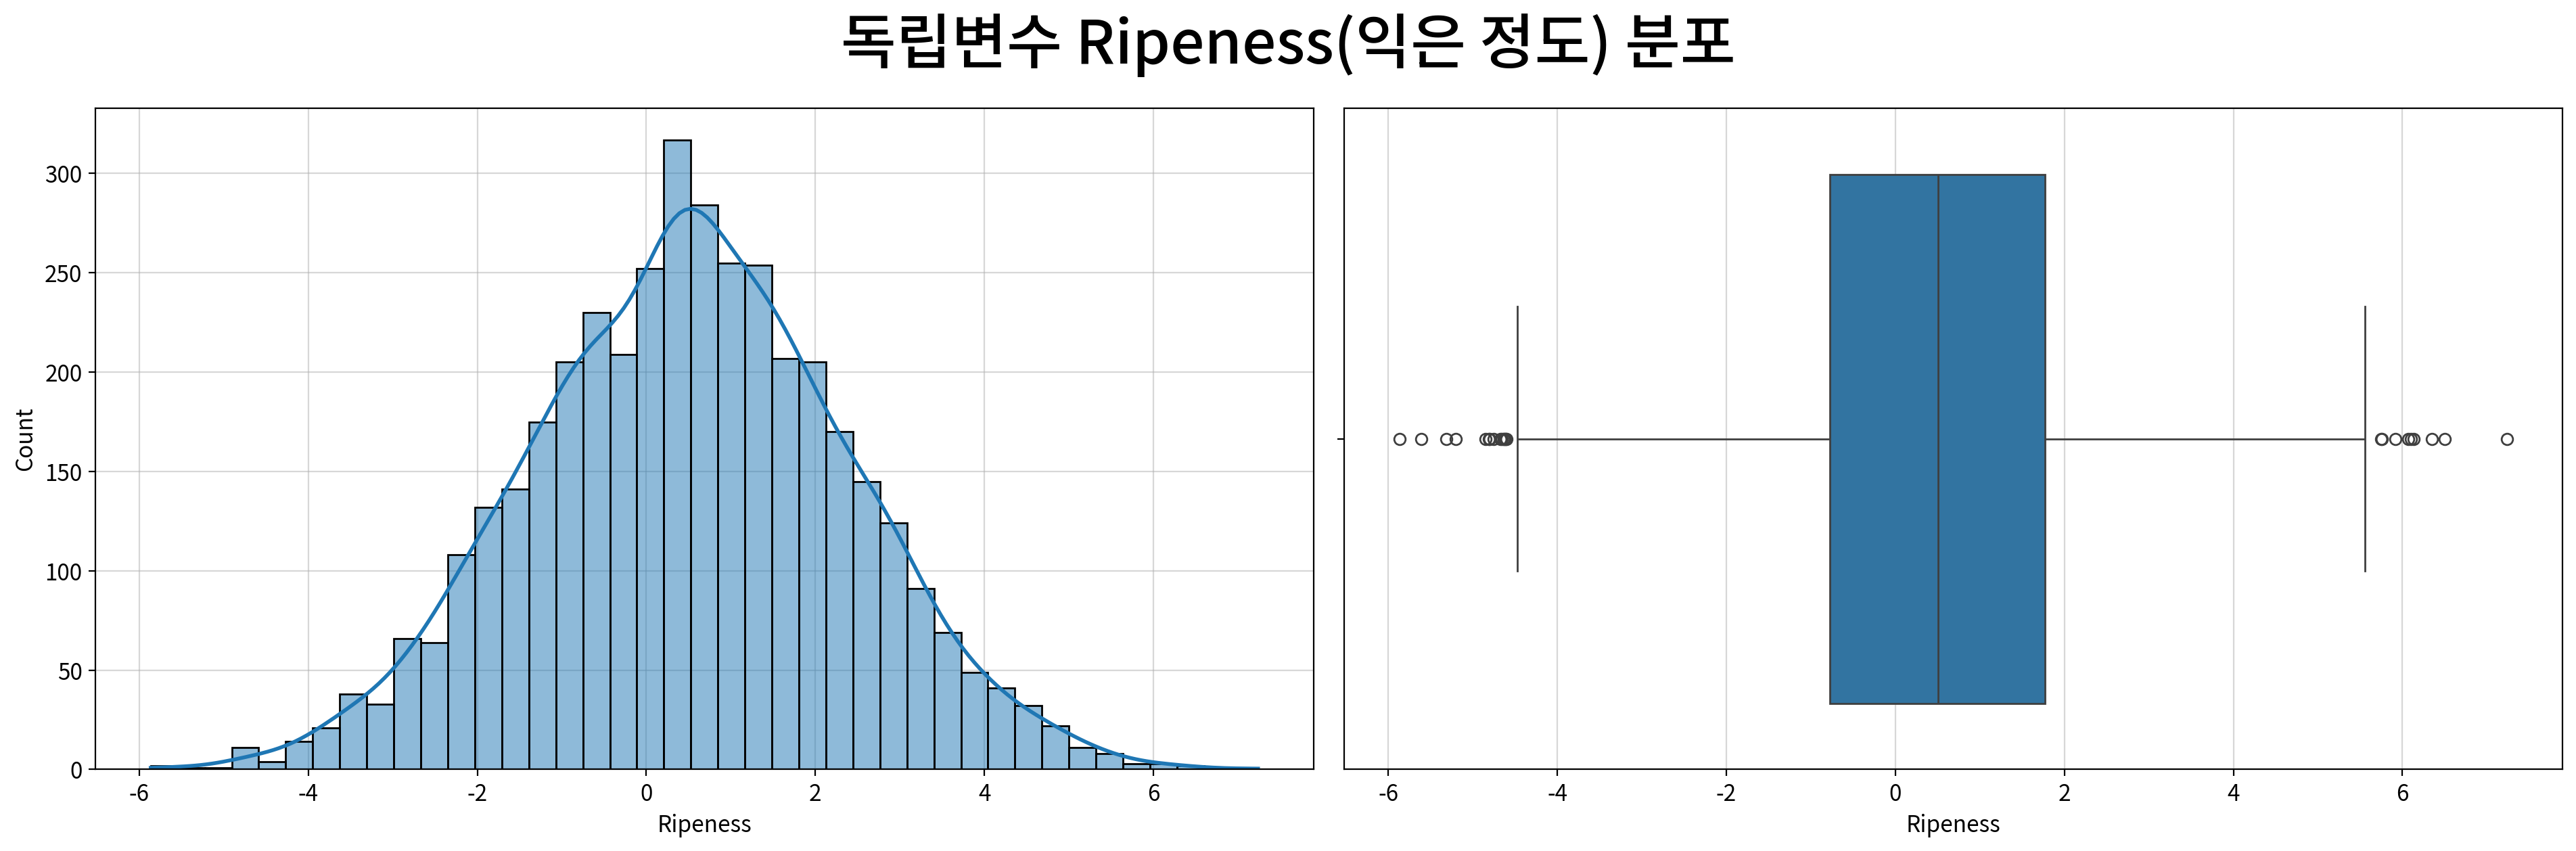

,Ripeness
count,4000.000
mean,0.498
std,1.874
min,-5.865
25%,-0.772
50%,0.503
75%,1.766
max,7.238
rel_diff,0.010
rdiff_flag,similar


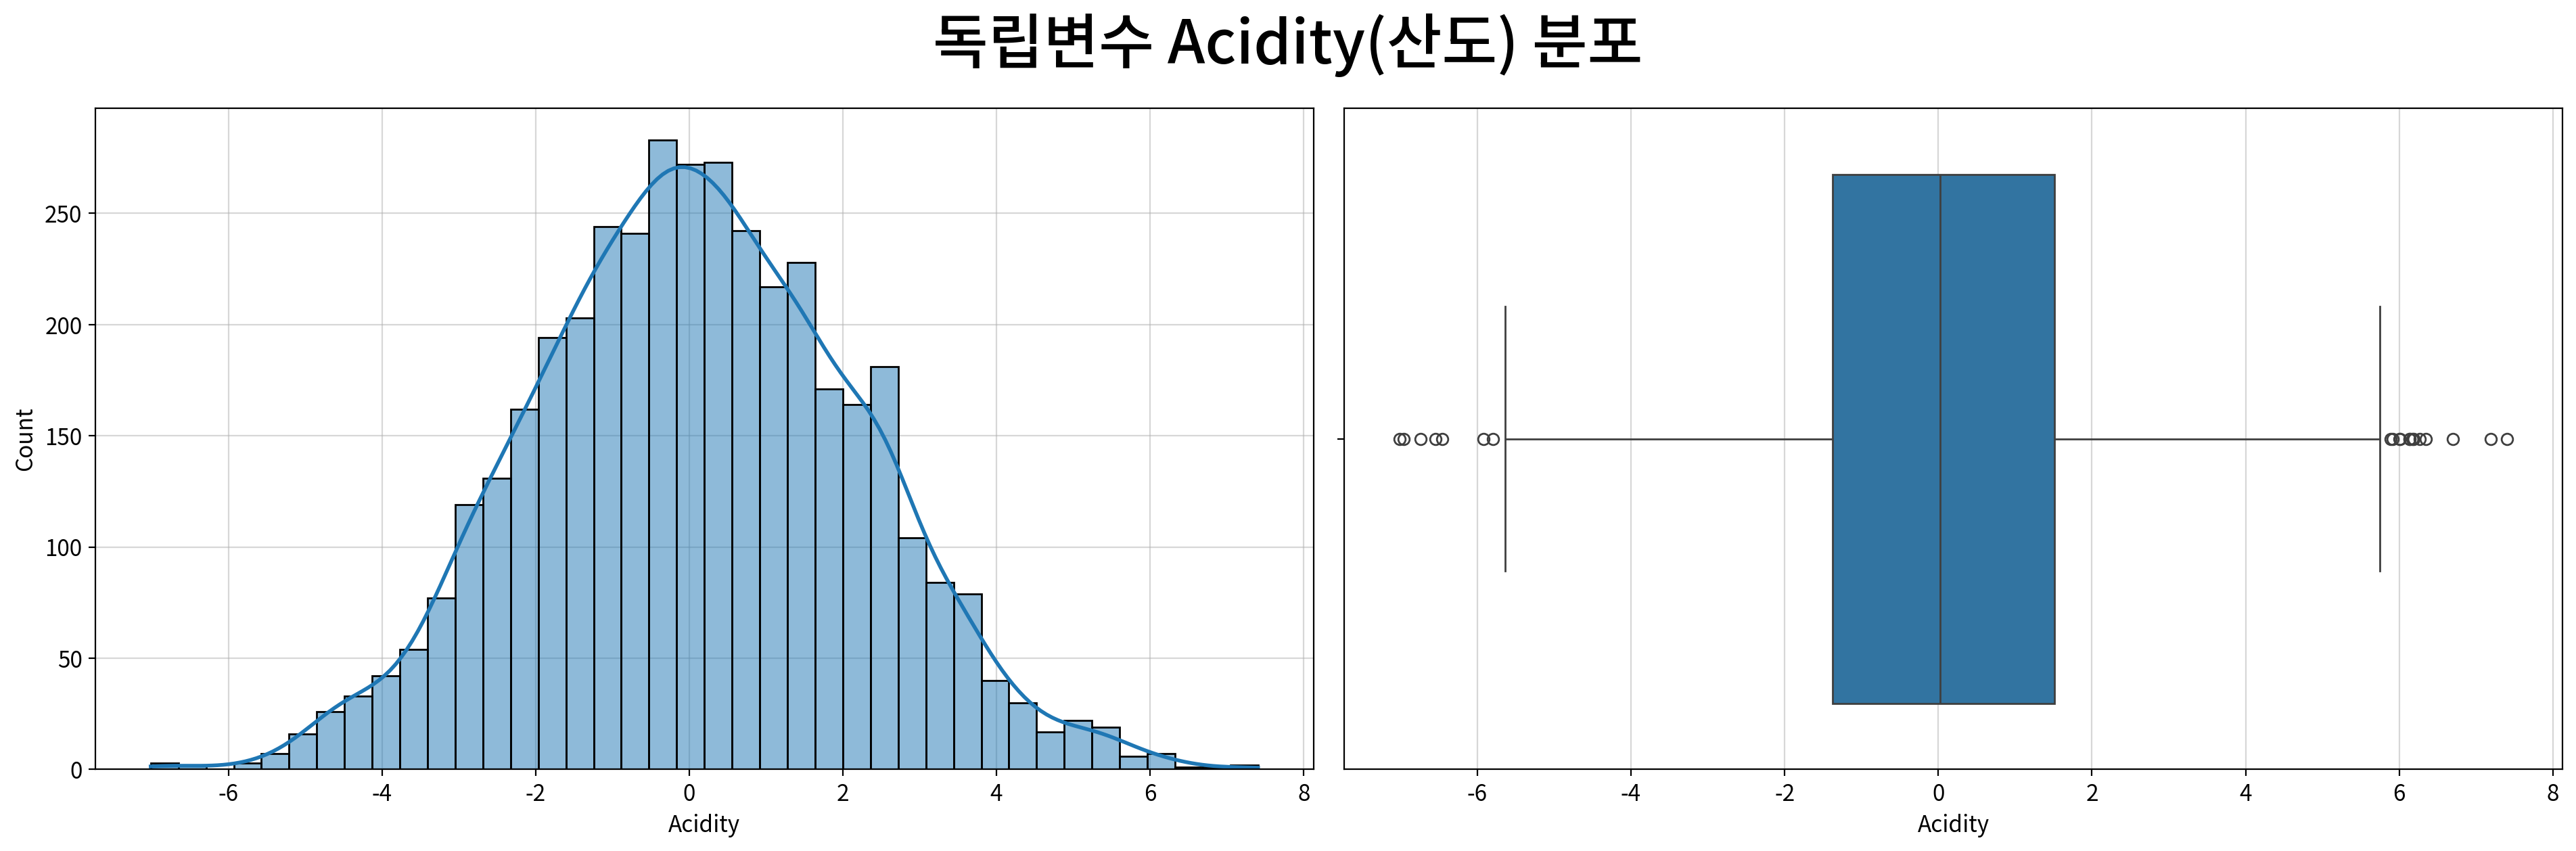

,Acidity
count,4000.000
mean,0.077
std,2.110
min,-7.011
25%,-1.377
50%,0.023
75%,1.510
max,7.405
rel_diff,2.400
rdiff_flag,large_diff


In [13]:
for f in continuous_cols:
    fix, ax = my_plot.init(rows=1, cols=2, width=960, height=640, title=f'독립변수 {f}({column_means[f]}) 분포')
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

## #05. 이변량 분석
### 1. T-Test (x:연속형 독립변수 → y:2집단 명목형 종속변수)
- 선형회귀에서 상관분석이 하던 역할('이 독립변수가 종속변수와 관련이 있는가')을 로지스틱 회귀에서는 T검정이 맡는다.

### ▶ Size(크기) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1433524.000    0.000         True  bad ≠ good
                    less        1433524.000    0.000         True  bad < good
                    greater     1433524.000    1.000        False  bad ≤ good

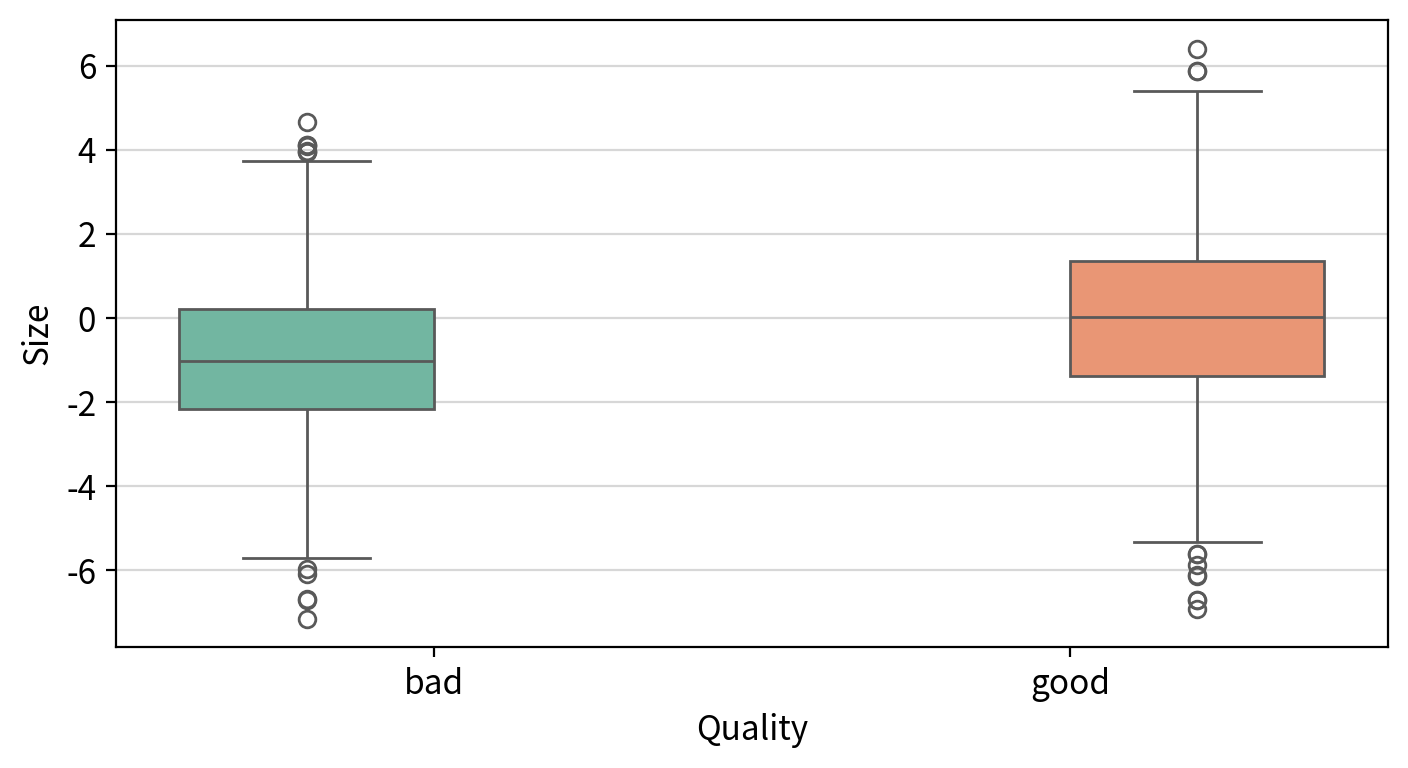

### ▶ Weight(무게) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided       -0.090    0.928        False  bad = good
             less            -0.090    0.464        False  bad ≥ good
             greater         -0.090    0.536        False  bad ≤ good

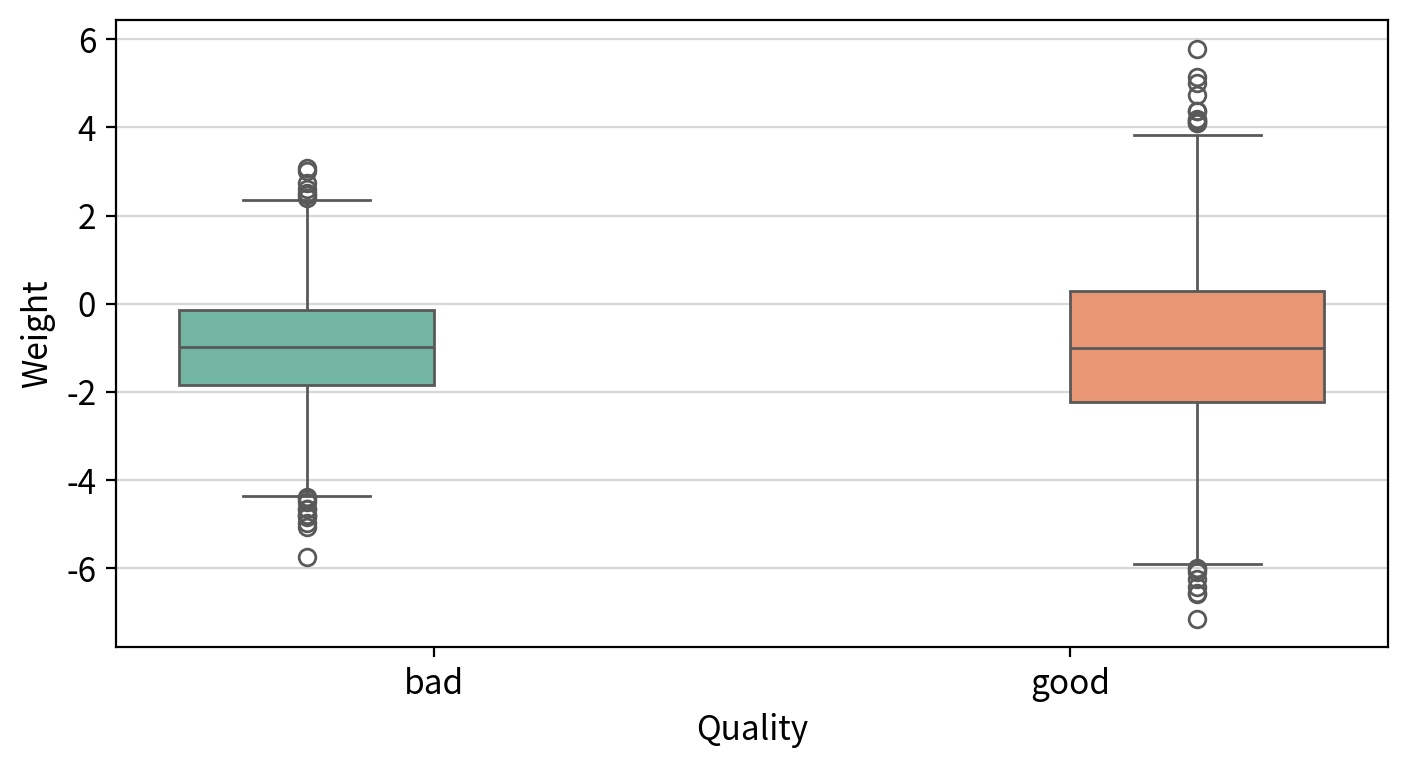

### ▶ Sweetness(단맛 정도) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1452149.000    0.000         True  bad ≠ good
                    less        1452149.000    0.000         True  bad < good
                    greater     1452149.000    1.000        False  bad ≤ good

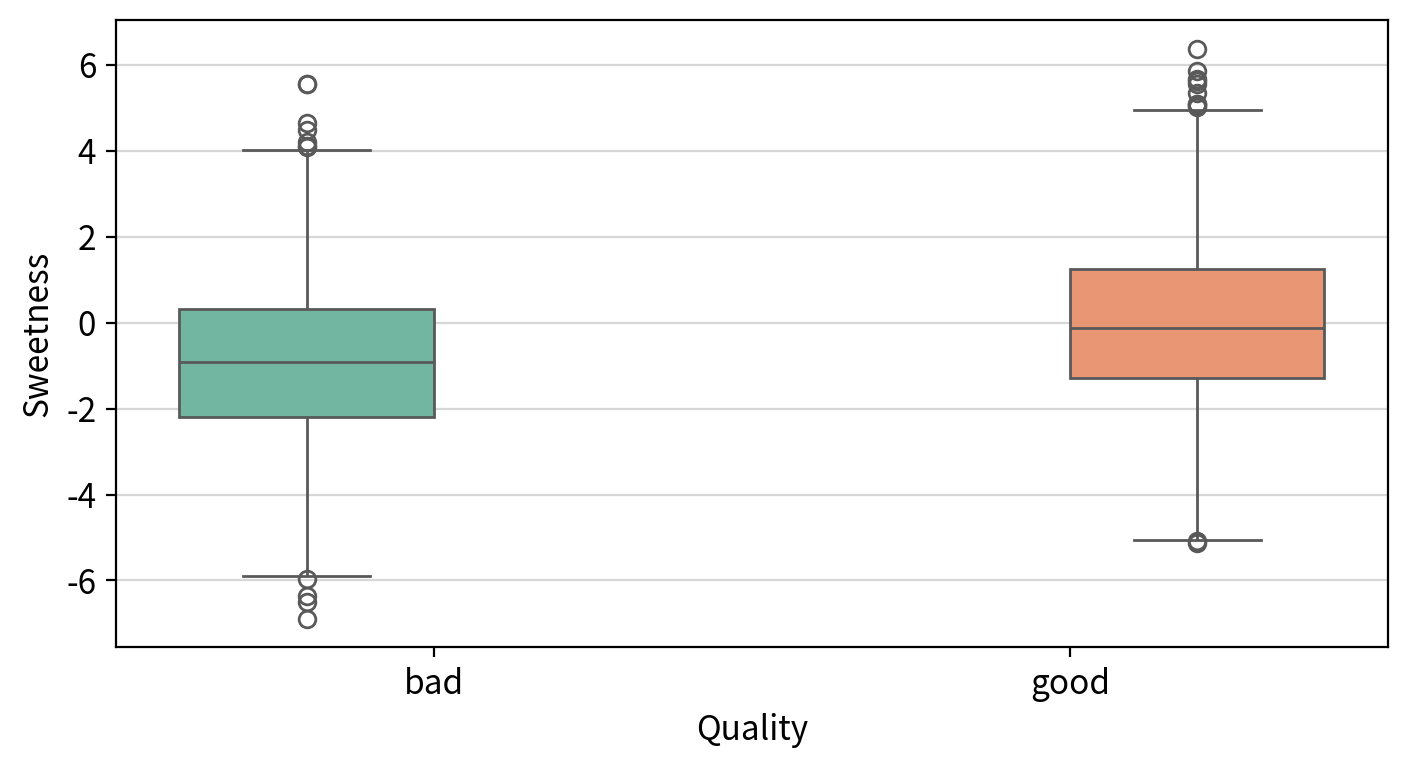

### ▶ Crunchiness(아삭한 식감) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1999316.000    0.985        False  bad = good
                    less        1999316.000    0.493        False  bad ≥ good
                    greater     1999316.000    0.507        False  bad ≤ good

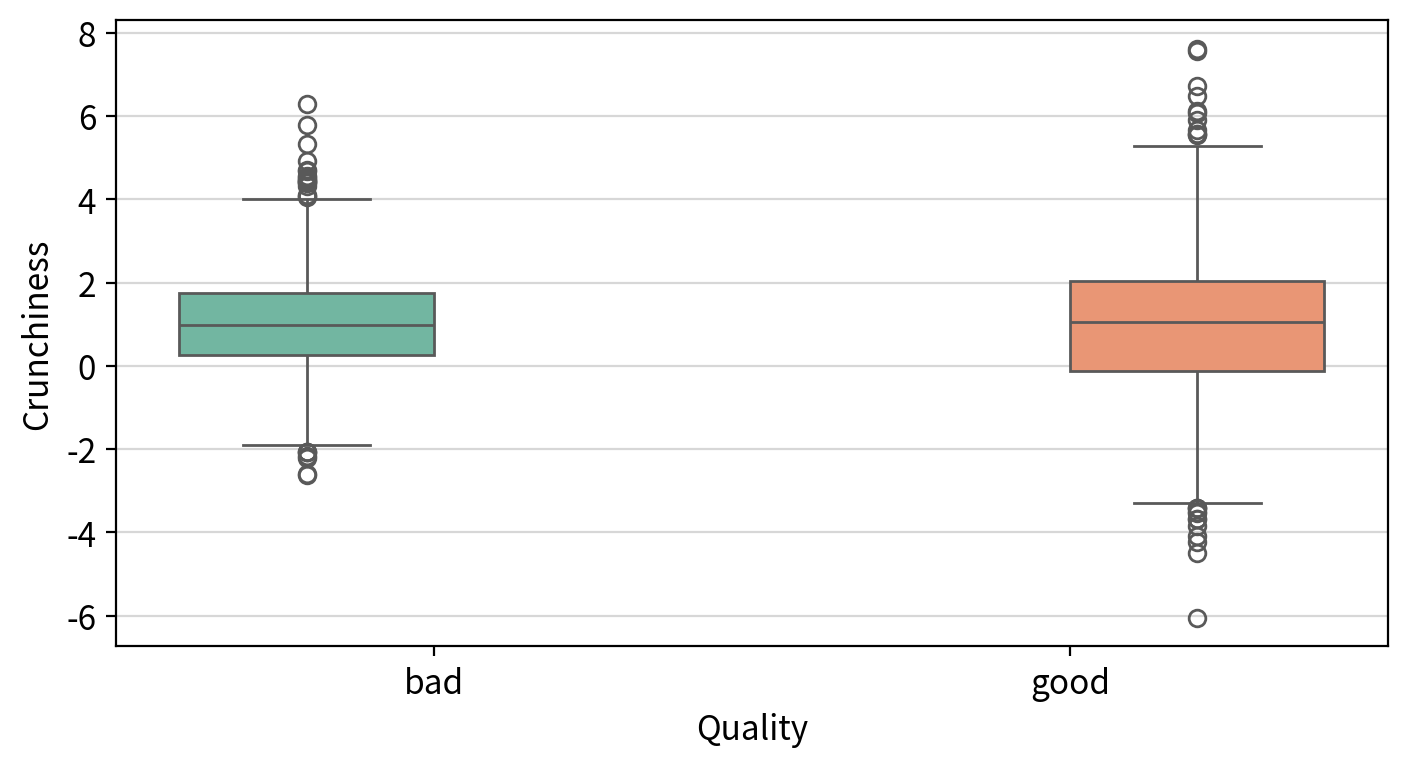

### ▶ Juiciness(과즙 함량) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided      -17.035    0.000         True  bad ≠ good
             less           -17.035    0.000         True  bad < good
             greater        -17.035    1.000        False  bad ≤ good

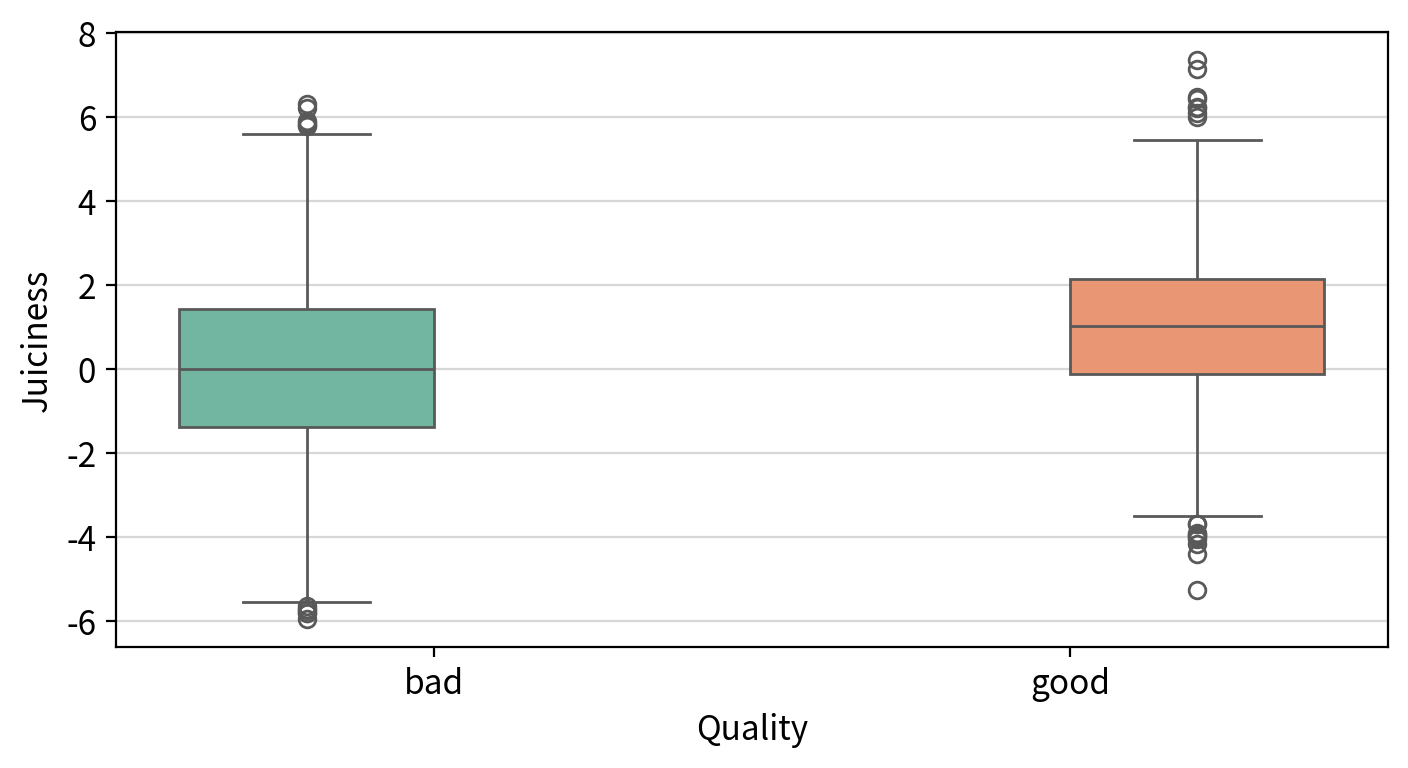

### ▶ Ripeness(익은 정도) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided       17.326    0.000         True  bad ≠ good
             less            17.326    1.000        False  bad ≥ good
             greater         17.326    0.000         True  bad > good

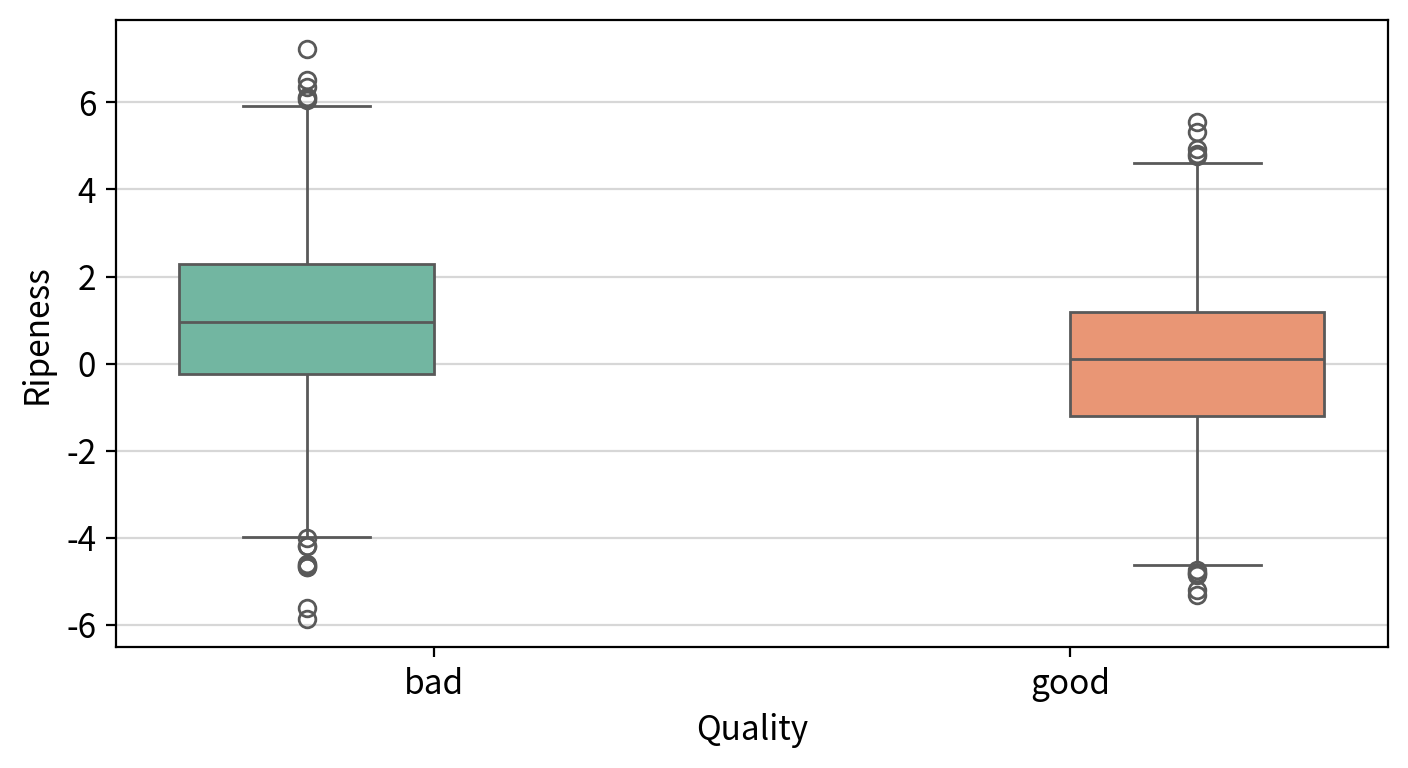

### ▶ Acidity(산도) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1990597.000    0.797        False  bad = good
                    less        1990597.000    0.399        False  bad ≥ good
                    greater     1990597.000    0.602        False  bad ≤ good

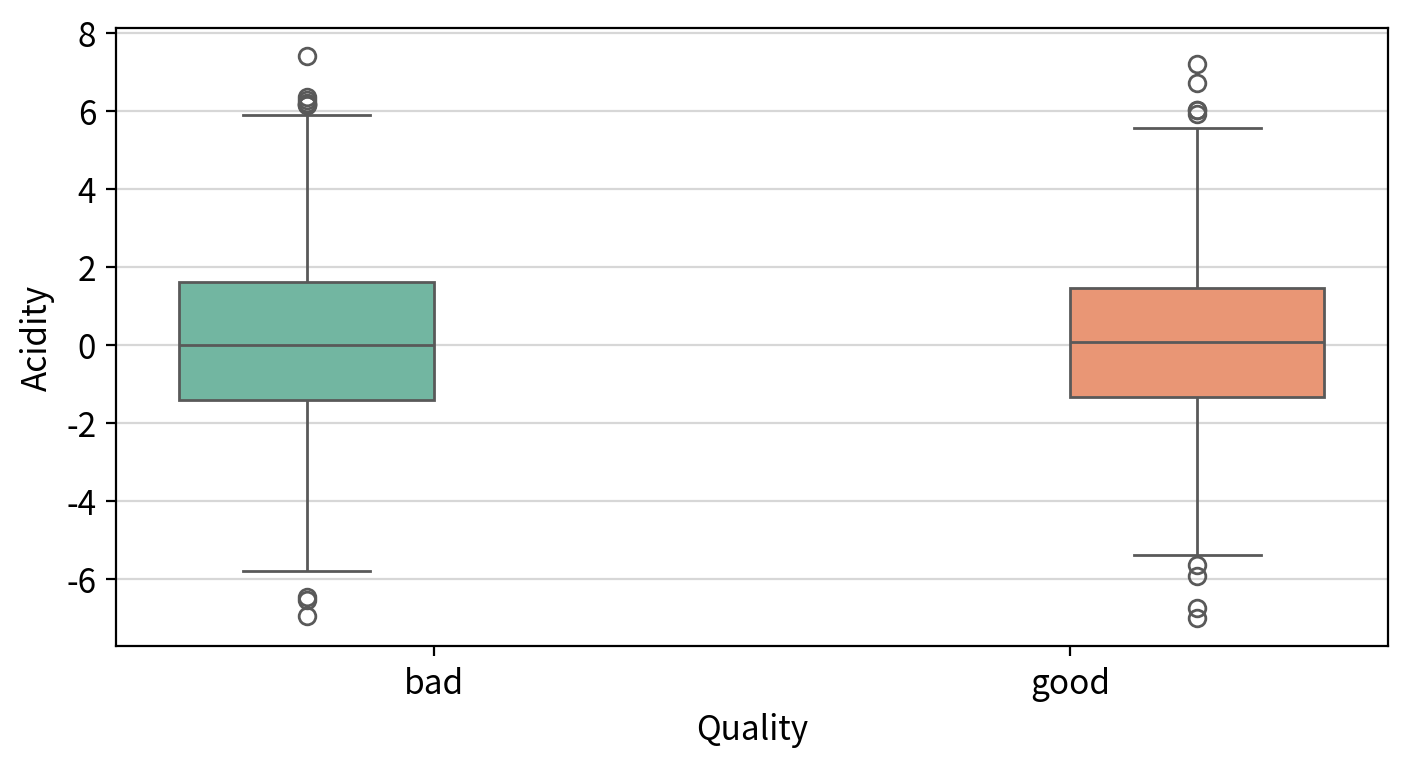

In [14]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f'### ▶ {f}({column_means[f]}) → {target}'))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # → 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df, group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette='Set2', width=720, height=400)
    

### 2. 교차분석 (x:명목형 독립변수 → y:명목형 종속변수)
- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.
- 명목형 독립변수가 없을 경우 출력 결과가 없을 수 있다.

In [15]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f'### ▶ {n}({column_means[n]}) → {target}'))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

## #06. 다변량 분석
### 1. 독립변수간 상관분석
- 연속형 독립변수끼리는 종속변수가 명목형이어도 상관분석을 그대로 쓸 수 있따.
- 목적이 다르다. 여기서는 설명력 확인이 아니라 다중공선성 점검이다.

In [16]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

method   coef  p-value  strength  significant  \
x           y                                                              
Size        Weight       Spearman -0.144    0.000      Weak         True   
            Sweetness     Pearson -0.325    0.000  Moderate         True   
            Crunchiness  Spearman  0.172    0.000      Weak         True   
            Juiciness    Spearman -0.032    0.044      Weak         True   
            Ripeness     Spearman -0.155    0.000      Weak         True   
            Acidity      Spearman  0.210    0.000      Weak         True   
Weight      Sweetness    Spearman -0.120    0.000      Weak         True   
            Crunchiness  Spearman -0.087    0.000      Weak         True   
            Juiciness    Spearman -0.091    0.000      Weak         True   
            Ripeness     Spearman -0.244    0.000      Weak         True   
            Acidity      Spearman  0.030    0.054      Weak        False   
Sweetness   Crunchiness  Spearman -0.017    0.273      Weak        False   
            Juiciness    Spearman  0.098    0.000      Weak         True   
            Ripeness     Spearman -0.255    0.000      Weak         True   
            Acidity      Spearman  0.072    0.000      Weak         True   
Crunchiness Juiciness    Spearman -0.236    0.000      Weak         True   
            Ripeness     Spearman -0.184    0.000      Weak         True   
            Acidity      Spearman  0.074    0.000      Weak         True   
Juiciness   Ripeness     Spearman -0.124    0.000      Weak         True   
            Acidity      Spearman  0.231    0.000      Weak         True   
Ripeness    Acidity      Spearman -0.195    0.000      Weak         True   

                         normality_x  normality_y  linearity  \
x           y                                                  
Size        Weight              True        False       True   
            Sweetness           True         True       True   
            Crunchiness         True        False      False   
            Juiciness           True        False      False   
            Ripeness            True         True      False   
            Acidity             True         True      False   
Weight      Sweetness          False         True      False   
            Crunchiness        False        False       True   
            Juiciness          False        False       True   
            Ripeness           False         True      False   
            Acidity            False         True       True   
Sweetness   Crunchiness         True        False      False   
            Juiciness           True        False       True   
            Ripeness            True         True      False   
            Acidity             True         True      False   
Crunchiness Juiciness          False        False       True   
            Ripeness           False         True      False   
            Acidity            False         True      False   
Juiciness   Ripeness           False         True      False   
            Acidity            False         True      False   
Ripeness    Acidity             True         True      False   

                         influential_outlier  high_skew  
x           y                                            
Size        Weight                     False      False  
            Sweetness                  False      False  
            Crunchiness                False      False  
            Juiciness                  False      False  
            Ripeness                   False      False  
            Acidity                    False      False  
Weight      Sweetness                  False      False  
            Crunchiness                False      False  
            Juiciness                  False      False  
            Ripeness                   False      False  
            Acidity                    False      False  
Sweetness   Crunchiness                False      F

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
Size,1.000,-0.144,-0.325,0.172,-0.032,-0.155,0.210
Weight,-0.144,1.000,-0.120,-0.087,-0.091,-0.244,0.030
Sweetness,-0.325,-0.120,1.000,-0.017,0.098,-0.255,0.072
Crunchiness,0.172,-0.087,-0.017,1.000,-0.236,-0.184,0.074
Juiciness,-0.032,-0.091,0.098,-0.236,1.000,-0.124,0.231
Ripeness,-0.155,-0.244,-0.255,-0.184,-0.124,1.000,-0.195
Acidity,0.210,0.030,0.072,0.074,0.231,-0.195,1.000


,max-y,max-coef,count,columns
x,,,,
Size,Sweetness,-0.325,0,-
Sweetness,Size,-0.325,0,-
Ripeness,Sweetness,-0.255,0,-
Weight,Ripeness,-0.244,0,-
Crunchiness,Juiciness,-0.236,0,-
Juiciness,Crunchiness,-0.236,0,-
Acidity,Juiciness,0.231,0,-


### 연습문제
- 6. 종속변수를 제외하고 나면, 탐색적 분석의 대상이 되는 연속형 독립변수는 몇개인가요? 7개
- 7. 종속변수를 제외하고 나면, 명목형 독립변수는 몇개인가요? 0개
- 8. 척도 조합표의 아홉가지 경우, 이 데이터에서 실제로 수행되는 분석 유형은 무엇인가요? T검정
- 9. 종속변수의 두 범주 중 더 많이 나타나는 쪽은 무엇인가요? good
- 10. 그 최빈 범주가 전체에서 차지하는 비율은 얼마인가요? (소수 셋째자리) 0.501
- 11. 7가지 연속형 독립변수 중 분포의 비대칭이 가장 큰(왜도의 절댓값이 가장 큰) 항목은 무엇인가요? Juiciness
- 12. 각 측정 항목이 good / bad 판정과 관련이 있는지 하나씩 검정했을 때, 두 집단 사이에 차이가 가장 없다고 나온 항목은 무엇인가요? Crunchiness
- 13. 유의수준 5% 기준으로, 두 집단 사이에 차이가 유의하다고 판정된 항목은 몇 개인가요? 4개
- 14. 유의하다고 판정된 4개 항목 중, 유일하게 bad 집단의 평균이 더 큰 항목은 무엇인가요? Ripeness(익은 정도)
- 15. 검정 전에 정규성과 등분산성을 먼저 확인하기 때문에, 항목마다 적용되는 검정 방법이 달라집니다. 정규성 가정을 만족하지 못해 순위 기반 비모수 검정으로 판정된 항목은 몇 개인가요? 4개
- 16. 연속형 독립변수끼리 상관관계를 확인했을 때, 강한 상관(절댓값 0.7 이상)으로 분류된 조합은 몇 개인가요? 0개
- 17. 독립변수 조합 중 상관계수의 절댓값이 가장 큰 값은 얼마인가요? -0.325
- 18. 이변량 분석 결과로 곧바로 채택할 수 있는 변수는 몇 개인가요? 4
- 19. 단독 비교에서는 차이가 없었지만, 제거하지 않고 보류로 두는 변수는 몇 개인가요? 3
- 20. 결국 모델에 투입되는 독립변수는 모두 몇 개인가요? 7